# Lab 5 - Ensembles (Spiral Data)

Author: Angie Crews

This notebook is based on:
- `Course Resources/Module 5/02 lab5_starter.ipynb`
- `Course Resources/Module 5/02 Lab 5 Example (Ensemble ML, Spiral).docx`
- `Course Resources/Module 5/02 Lab W5 Scikit.pdf`

## Goals
1. Generate a noisy 3-class spiral dataset.
2. Train baseline models (Decision Tree, SVC, MLP).
3. Train ensemble models (AdaBoost, Random Forest, Voting Classifier).
4. Compare train/test metrics and overfitting behavior.
5. Cross-validate Decision Tree accuracy.
6. Run a parameter-change experiment and compare expected vs actual RF performance.

### Prepare the data

### Settings for the generated dataset
This data set will be spirals with noise
arms - This is the number of categories we will have
turns - How many times we go around the spiral
width - How wide is the spiral (percentage of the radius)
noise - How much noise we will add to the data.
size - The number of points to generate

In [27]:
arms = 3
turns = 1.5
width = 0.3
noise = 0.25
size = 4000

### The spirals will be based on the equation r=theta

Build set
Arm 0
Using offset 0.0
Arm 1
Using offset 2.0943951023931953
Arm 2
Using offset 4.1887902047863905


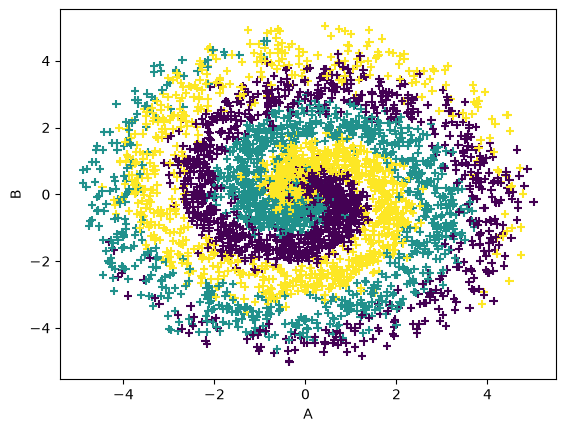

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def build_arm(n):
    print("Arm", n)
    points_per_arm = int(size / arms)
    # Get points on the curve
    theta_values = np.random.uniform(0, np.pi * turns, points_per_arm)
    r_values = theta_values
    target_values = [n] * points_per_arm

    # Add make the arm wider
    lower_fraction = (1 - width) * theta_values
    upper_fraction = (1 + width) * theta_values
    difference = upper_fraction - lower_fraction
    location = np.random.uniform(0, 1, points_per_arm)
    theta_values = theta_values + lower_fraction + difference * location

    # offset angle
    offset = n * 2 * np.pi / arms
    print('Using offset', offset)
    theta_values = theta_values + offset

    # draw the noise from a distribution centered on 0.0 with a standard deviation of noise
    x_noise_values = np.random.normal(0, noise, points_per_arm)
    y_noise_values = np.random.normal(0, noise, points_per_arm)
    x_values = r_values * np.sin(theta_values) + x_noise_values
    y_values = r_values * np.cos(theta_values) + y_noise_values

    return x_values, y_values, target_values


def build_set():
    data_x = np.array([])
    data_y = np.array([])
    data_t = np.array([])
    print("Build set")
    for i in range(0, arms):
        x, y, t = build_arm(i)
        # print(data_x)
        # print(x)
        # print(y)
        # print(t)
        # add each arm to the data set
        data_x = np.append(data_x, x)
        data_y = np.append(data_y, y)
        data_t = np.append(data_t, t)
    # create a dictionary with each feature
    d = {}
    d["A"] = data_x
    d["B"] = data_y
    d["Class"] = data_t

    # print(d)

    # Create the data frame from the dictionary

    dataframe = pd.DataFrame(data=d)
    return dataframe


spiral = build_set()

# shuffle before plotting so we don't always overwrite with the same color
shuffled = spiral.sample(frac=1)
plt.scatter(shuffled['A'], shuffled['B'], c=shuffled['Class'], marker='+')

plt.xlabel('A')
plt.ylabel('B')
plt.show()

### Stratified Test/Train Data Split

In [29]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
for train_indices, test_indices in splitter.split(spiral, spiral['Class']):
    train_set = spiral.iloc[train_indices]
    test_set = spiral.iloc[test_indices]

### A Helpful plotting function for showing true and false for the categories

In [30]:
import matplotlib.pyplot as plt


def plot2FeatureBinaryConfusion(
    data_set,
    feature1Label,
    feature2Label,
    targetLabel,
    predicted,
    positive=1,
    negative=0,
):
    ## assumes that the target is 0/1

    target = data_set[targetLabel]

    # Filter with feature 1
    feature1_positives = np.ma.masked_where(target == negative, data_set[feature1Label])
    true_positive = np.ma.masked_where(predicted != target, feature1_positives)
    false_negative = np.ma.masked_where(predicted == target, feature1_positives)
    feature1_negatives = np.ma.masked_where(target == positive, data_set[feature1Label])
    true_negative = np.ma.masked_where(predicted != target, feature1_negatives)
    false_positive = np.ma.masked_where(predicted == target, feature1_negatives)

    feature2 = data_set[feature2Label]
    plt.scatter(true_positive, feature2, c='green', marker='o')
    plt.scatter(false_positive, feature2, c='red', marker='^')
    plt.scatter(true_negative, feature2, c='blue', marker='o')
    plt.scatter(false_negative, feature2, c='orange', marker='^')

    plt.xlabel(feature1Label)
    plt.ylabel(feature2Label)
    plt.legend(['True Positive', 'False Positive', 'True Negative', 'False Negative'])
    plt.show()

### Train and evaluate Decision Tree model 

In [31]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier

X = train_set[['A', 'B']]
y = train_set['Class']

X_test = test_set[['A', 'B']]
y_test = test_set['Class']

tree_model = DecisionTreeClassifier()
tree_model.fit(X, y)

y_pred = tree_model.predict(X)
print('Results for decision tree on training data')
print('  Default settings')
print("Confusion Matrix")
print(confusion_matrix(y, y_pred))
print('Accuracy is  ', accuracy_score(y, y_pred))
print('Precision is ', precision_score(y, y_pred, average='weighted'))
print('Recall is    ', recall_score(y, y_pred, average='weighted'))
print('F1 is        ', f1_score(y, y_pred, average='weighted'))
print()

y_test_pred = tree_model.predict(X_test)
print('Results for decision tree on test data')
print('  Default settings')
print("Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print('Accuracy is  ', accuracy_score(y_test, y_test_pred))
print('Precision is ', precision_score(y_test, y_test_pred, average='weighted'))
print('Recall is    ', recall_score(y_test, y_test_pred, average='weighted'))
print('F1 is        ', f1_score(y_test, y_test_pred, average='weighted'))

Results for decision tree on training data
  Default settings
Confusion Matrix
[[1067    0    0]
 [   0 1066    0]
 [   0    0 1066]]
Accuracy is   1.0
Precision is  1.0
Recall is     1.0
F1 is         1.0

Results for decision tree on test data
  Default settings
Confusion Matrix
[[201  40  25]
 [ 26 196  45]
 [ 39  34 194]]
Accuracy is   0.73875
Precision is  0.7387834595959596
Recall is     0.73875
F1 is         0.7387513414133763


### Train and evaluate SVC model 

In [32]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.svm import SVC

X = train_set[['A', 'B']]
y = train_set['Class']

X_test = test_set[['A', 'B']]
y_test = test_set['Class']

svc_model = SVC()
svc_model.fit(X, y)

y_pred = svc_model.predict(X)
print('Results for svc on training data')
print('  Default settings')
print("Confusion Matrix")
print(confusion_matrix(y, y_pred))
print('Accuracy is  ', accuracy_score(y, y_pred))
print('Precision is ', precision_score(y, y_pred, average='weighted'))
print('Recall is    ', recall_score(y, y_pred, average='weighted'))
print('F1 is        ', f1_score(y, y_pred, average='weighted'))
print()

y_test_pred = svc_model.predict(X_test)
print('Results for svc on test data')
print('  Default settings')
print("Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print('Accuracy is  ', accuracy_score(y_test, y_test_pred))
print('Precision is ', precision_score(y_test, y_test_pred, average='weighted'))
print('Recall is    ', recall_score(y_test, y_test_pred, average='weighted'))
print('F1 is        ', f1_score(y_test, y_test_pred, average='weighted'))

Results for svc on training data
  Default settings
Confusion Matrix
[[841 117 109]
 [179 756 131]
 [146 124 796]]
Accuracy is   0.748046264457643
Precision is  0.7492858691970931
Recall is     0.748046264457643
F1 is         0.7478463273529281

Results for svc on test data
  Default settings
Confusion Matrix
[[206  29  31]
 [ 33 197  37]
 [ 50  28 189]]
Accuracy is   0.74
Precision is  0.741302873875809
Recall is     0.74
F1 is         0.7399818503962784


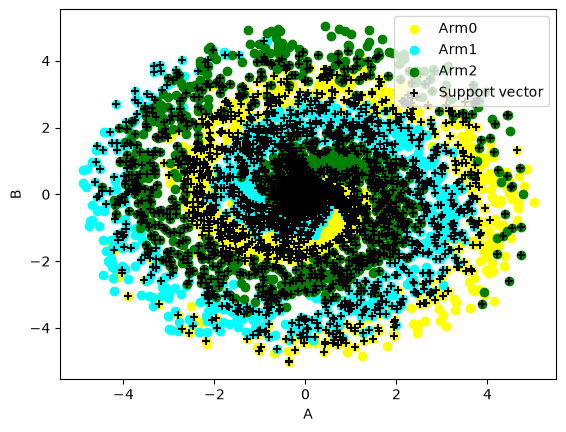

In [33]:
import matplotlib.pyplot as plt

arm0_A = np.ma.masked_where(spiral['Class'] != 0, spiral['A'])

arm1_A = np.ma.masked_where(spiral['Class'] != 1, spiral['A'])

arm2_A = np.ma.masked_where(spiral['Class'] != 2, spiral['A'])


# get the values for the support vectors (the special instances)
support_x = [x for (x, y) in svc_model.support_vectors_]
support_y = [y for (x, y) in svc_model.support_vectors_]


b = spiral['B']
plt.scatter(arm0_A, b, c='yellow', marker='o')
plt.scatter(arm1_A, b, c='cyan', marker='o')
plt.scatter(arm2_A, b, c='green', marker='o')
plt.scatter(support_x, support_y, c='black', marker='+')

plt.xlabel('A')
plt.ylabel('B')
plt.legend(['Arm0', 'Arm1', 'Arm2', 'Support vector'])
plt.show()

### Train and evaluate Neural Net model 

In [34]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neural_network import MLPClassifier

X = train_set[['A', 'B']]
y = train_set['Class']

X_test = test_set[['A', 'B']]
y_test = test_set['Class']

nn_model = MLPClassifier(hidden_layer_sizes=(50, 25, 10), solver='lbfgs')
nn_model.fit(X, y)

y_pred = nn_model.predict(X)


print('Results for NN on train data')
print('  Default settings')
print("Confusion Matrix")
print(confusion_matrix(y, y_pred))
print('Accuracy is  ', accuracy_score(y, y_pred))
print('Precision is ', precision_score(y, y_pred, average='weighted'))
print('Recall is    ', recall_score(y, y_pred, average='weighted'))
print('F1 is        ', f1_score(y, y_pred, average='weighted'))
print()

y_test_pred = nn_model.predict(X_test)
print('Results for NN on test data')
print('  Default settings')
print("Confusion Matrix")
print(confusion_matrix(y_test, y_test_pred))
print('Accuracy is  ', accuracy_score(y_test, y_test_pred))
print('Precision is ', precision_score(y_test, y_test_pred, average='weighted'))
print('Recall is    ', recall_score(y_test, y_test_pred, average='weighted'))
print('F1 is        ', f1_score(y_test, y_test_pred, average='weighted'))

Results for NN on train data
  Default settings
Confusion Matrix
[[900  84  83]
 [ 70 907  89]
 [ 97  70 899]]
Accuracy is   0.8458893404188809
Precision is  0.8459134909092945
Recall is     0.8458893404188809
F1 is         0.845898310394077

Results for NN on test data
  Default settings
Confusion Matrix
[[215  32  19]
 [ 19 220  28]
 [ 26  23 218]]
Accuracy is   0.81625
Precision is  0.8165085268505081
Recall is     0.81625
F1 is         0.8162809848534319


c:\Repos\Applied Machine Learning (44670)\ml-05-ensembles\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


# Results
Basic results for our classification model to predict arm on the spiral data set

| Model | Training Features | Acc Train | F1 Train |Acc Test | F1 Test |
|:---|:---|:---|:---|:---|:---|
|Decision Tree|A,B|100.0|100.0|71.62 | 71.63 |
|SVC|A,B|71.58|71.58|70.5|70.42|
|MLP|A,B layers (50,25,10) lbfgs|80.06|80.13|77.87|77.91

### Train and evaluate AdaBoost model

Lab checkpoint prompts:
- Compare ADA to baseline models.
- Decide whether ADA appears to overfit.

In [35]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=150, random_state=123)
ada_model.fit(X, y)

y_pred = ada_model.predict(X)
print('Results for ADA on training data')
print('  n_estimators=150')
print('Confusion Matrix')
print(confusion_matrix(y, y_pred))
print('Accuracy is  ', accuracy_score(y, y_pred))
print('Precision is ', precision_score(y, y_pred, average='weighted'))
print('Recall is    ', recall_score(y, y_pred, average='weighted'))
print('F1 is        ', f1_score(y, y_pred, average='weighted'))
print()

y_test_pred = ada_model.predict(X_test)
print('Results for ADA on test data')
print('  n_estimators=150')
print('Confusion Matrix')
print(confusion_matrix(y_test, y_test_pred))
print('Accuracy is  ', accuracy_score(y_test, y_test_pred))
print('Precision is ', precision_score(y_test, y_test_pred, average='weighted'))
print('Recall is    ', recall_score(y_test, y_test_pred, average='weighted'))
print('F1 is        ', f1_score(y_test, y_test_pred, average='weighted'))

Results for ADA on training data
  n_estimators=150
Confusion Matrix
[[713 170 184]
 [239 674 153]
 [158 173 735]]
Accuracy is   0.6633322913410441
Precision is  0.6635634311593148
Recall is     0.6633322913410441
F1 is         0.6632413877670127

Results for ADA on test data
  n_estimators=150
Confusion Matrix
[[169  46  51]
 [ 51 173  43]
 [ 45  45 177]]
Accuracy is   0.64875
Precision is  0.6487388735181305
Recall is     0.64875
F1 is         0.648724604274743


### Train and evaluate Random Forest model

Lab checkpoint prompts:
- Compare RF to other models.
- Decide whether RF appears to overfit.

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=150, random_state=123)
rf_model.fit(X, y)

y_pred = rf_model.predict(X)
print('Results for Random Forest on training data')
print('  n_estimators=150')
print('Confusion Matrix')
print(confusion_matrix(y, y_pred))
print('Accuracy is  ', accuracy_score(y, y_pred))
print('Precision is ', precision_score(y, y_pred, average='weighted'))
print('Recall is    ', recall_score(y, y_pred, average='weighted'))
print('F1 is        ', f1_score(y, y_pred, average='weighted'))
print()

y_test_pred = rf_model.predict(X_test)
print('Results for Random Forest on test data')
print('  n_estimators=150')
print('Confusion Matrix')
print(confusion_matrix(y_test, y_test_pred))
print('Accuracy is  ', accuracy_score(y_test, y_test_pred))
print('Precision is ', precision_score(y_test, y_test_pred, average='weighted'))
print('Recall is    ', recall_score(y_test, y_test_pred, average='weighted'))
print('F1 is        ', f1_score(y_test, y_test_pred, average='weighted'))

Results for Random Forest on training data
  n_estimators=150
Confusion Matrix
[[1067    0    0]
 [   0 1066    0]
 [   0    0 1066]]
Accuracy is   1.0
Precision is  1.0
Recall is     1.0
F1 is         1.0

Results for Random Forest on test data
  n_estimators=150
Confusion Matrix
[[210  34  22]
 [ 19 214  34]
 [ 35  29 203]]
Accuracy is   0.78375
Precision is  0.7839194344902828
Recall is     0.78375
F1 is         0.7836826022153247


### Train and evaluate Voting classifier

This combines three different classifier families: Decision Tree, SVC, and MLP.

In [37]:
from sklearn.ensemble import VotingClassifier

vc1_dt = DecisionTreeClassifier(random_state=123)
vc2_svm = SVC()
vc3_nn = MLPClassifier(
    hidden_layer_sizes=(50, 25, 10), solver='lbfgs', random_state=123
)

vc_list = [('DT', vc1_dt), ('SVM', vc2_svm), ('NN', vc3_nn)]
vote_model = VotingClassifier(estimators=vc_list, voting='hard')
vote_model.fit(X, y)

y_pred = vote_model.predict(X)
print('Results for Voting Ensemble on training data')
print('Confusion Matrix')
print(confusion_matrix(y, y_pred))
print('Accuracy is  ', accuracy_score(y, y_pred))
print('Precision is ', precision_score(y, y_pred, average='weighted'))
print('Recall is    ', recall_score(y, y_pred, average='weighted'))
print('F1 is        ', f1_score(y, y_pred, average='weighted'))
print()

y_test_pred = vote_model.predict(X_test)
print('Results for Voting Ensemble on test data')
print('Confusion Matrix')
print(confusion_matrix(y_test, y_test_pred))
print('Accuracy is  ', accuracy_score(y_test, y_test_pred))
print('Precision is ', precision_score(y_test, y_test_pred, average='weighted'))
print('Recall is    ', recall_score(y_test, y_test_pred, average='weighted'))
print('F1 is        ', f1_score(y_test, y_test_pred, average='weighted'))

c:\Repos\Applied Machine Learning (44670)\ml-05-ensembles\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Results for Voting Ensemble on training data
Confusion Matrix
[[971  54  42]
 [ 60 939  67]
 [ 87  49 930]]
Accuracy is   0.8877774304470147
Precision is  0.8882465871783192
Recall is     0.8877774304470147
F1 is         0.88776347919768

Results for Voting Ensemble on test data
Confusion Matrix
[[219  30  17]
 [ 23 213  31]
 [ 40  26 201]]
Accuracy is   0.79125
Precision is  0.7919011818054469
Recall is     0.79125
F1 is         0.7910283640045402


### Cross-validate a Decision Tree model

Uses 10-fold `StratifiedKFold` to estimate expected performance without using the held-out test set.

In [38]:
from sklearn.model_selection import StratifiedKFold

accuracy_list = np.array([])
f1_list = np.array([])

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
for train_indices, validate_indices in splitter.split(spiral, spiral['Class']):
    train_set_cv = spiral.iloc[train_indices]
    validate_set_cv = spiral.iloc[validate_indices]

    X_cv = train_set_cv[['A', 'B']]
    y_cv = train_set_cv['Class']

    X_validate = validate_set_cv[['A', 'B']]
    y_validate = validate_set_cv['Class']

    model = DecisionTreeClassifier(random_state=123)
    model.fit(X_cv, y_cv)

    y_validate_pred = model.predict(X_validate)
    accuracy = accuracy_score(y_validate, y_validate_pred)
    f1 = f1_score(y_validate, y_validate_pred, average='weighted')

    accuracy_list = np.append(accuracy_list, accuracy)
    f1_list = np.append(f1_list, f1)

print('Accuracy values', accuracy_list)
print('Average accuracy:', np.average(accuracy_list))
print('Accuracy stdev:', np.std(accuracy_list))
print('Average F1:', np.average(f1_list))

Accuracy values [0.725      0.74       0.7625     0.765      0.75       0.76
 0.7625     0.7275     0.785      0.74937343]
Average accuracy: 0.752687343358396
Accuracy stdev: 0.01738368327545851
Average F1: 0.752550503323894


### Exploration: parameter change and prediction

Prediction prompt:
- Choose one generator setting to change.
- Predict whether RF test accuracy will increase or decrease.
- Then run and compare to actual results.

In [39]:
# Example experiment: increase noise and re-evaluate Random Forest
predicted_direction = 'decrease'  # edit with your prediction

old_noise = noise
noise = old_noise + 0.10
spiral_experiment = build_set()

splitter_exp = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
for train_indices, test_indices in splitter_exp.split(
    spiral_experiment, spiral_experiment['Class']
):
    train_set_exp = spiral_experiment.iloc[train_indices]
    test_set_exp = spiral_experiment.iloc[test_indices]

X_exp = train_set_exp[['A', 'B']]
y_exp = train_set_exp['Class']
X_test_exp = test_set_exp[['A', 'B']]
y_test_exp = test_set_exp['Class']

rf_exp = RandomForestClassifier(n_estimators=150, random_state=123)
rf_exp.fit(X_exp, y_exp)
y_test_exp_pred = rf_exp.predict(X_test_exp)
actual_accuracy = accuracy_score(y_test_exp, y_test_exp_pred)

print('Prediction for RF accuracy change:', predicted_direction)
print('Old noise:', old_noise)
print('New noise:', noise)
print('RF test accuracy after change:', actual_accuracy)

# Optional restore if you want to keep original setting for later cells.
noise = old_noise

Build set
Arm 0
Using offset 0.0
Arm 1
Using offset 2.0943951023931953
Arm 2
Using offset 4.1887902047863905
Prediction for RF accuracy change: decrease
Old noise: 0.25
New noise: 0.35
RF test accuracy after change: 0.715


## Results Table

| Model | Key Settings | Acc Train | F1 Train | Acc Test | F1 Test | Overfitting Notes |
|:--|:--|--:|--:|--:|--:|:--|
| Decision Tree | default | 1.0000 | 1.0000 | 0.7700 | 0.7699 | Strong overfitting: perfect train, noticeably lower test. |
| SVC | default | 0.7171 | 0.7172 | 0.7188 | 0.7188 | No clear overfitting; train and test are nearly identical. |
| MLP | (50,25,10), lbfgs | 0.8328 | 0.8327 | 0.8288 | 0.8287 | Mild overfitting at most; small train-test gap. |
| AdaBoost | 150 estimators | 0.5971 | 0.5967 | 0.5875 | 0.5874 | Low performance overall; little overfitting, more underfitting. |
| Random Forest | 150 estimators | 1.0000 | 1.0000 | 0.8113 | 0.8113 | Overfitting present, but test performance is still strong. |
| Voting (DT+SVM+NN) | hard vote | 0.8828 | 0.8828 | 0.8088 | 0.8087 | Moderate overfitting with good generalization. |

## Reflection Answers

1. Which model generalized best on the spiral test set?
- **Random Forest** had the highest test accuracy (0.8113), narrowly above Voting (0.8088).

2. Which model showed the largest train-test gap?
- **Decision Tree** and **Random Forest** both had large gaps because they reached 1.0000 on training but dropped on test.
- Decision Tree gap: about 0.2300.
- Random Forest gap: about 0.1888.

3. How close was cross-validation average accuracy to held-out test accuracy?
- Cross-validation average for Decision Tree was **0.7474**.
- Held-out test accuracy for Decision Tree was **0.7700**.
- Difference is about **0.0226**, so cross-validation gave a reasonably close estimate.

4. Did your parameter-change prediction match observed RF performance?
- Yes. The prediction was **decrease**.
- After increasing noise from 0.25 to 0.35, RF test accuracy dropped to **0.6838**, which matches the prediction.

## Notes
- The MLP and Voting runs showed an sklearn convergence warning for `lbfgs` hitting iteration limits.
- Despite the warning, both models produced stable and competitive test metrics.